Saved:
/home/shahao/projects/DECODE-Plex/results/training_time/training_metrics_plot.eps
/home/shahao/projects/DECODE-Plex/results/training_time/training_metrics_plot.png


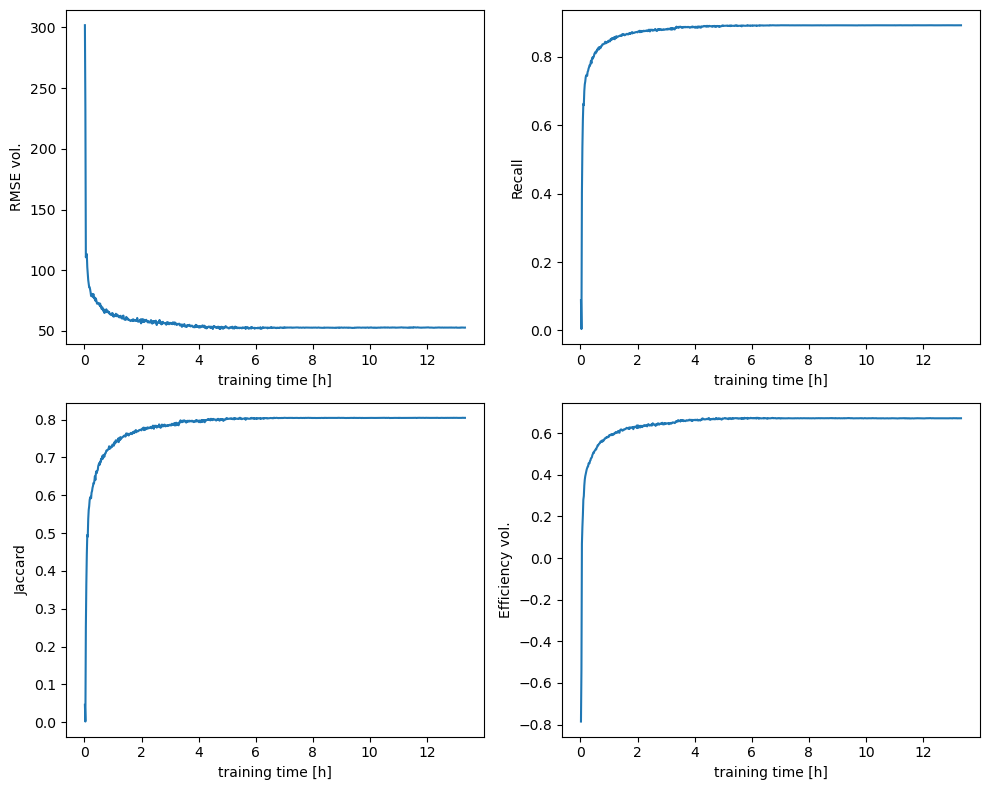

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/shahao/projects/DECODE-Plex/data/0.csv"

# Read CSV with multi-row header handling
raw = pd.read_csv(csv_path, header=None)

# Construct dataframe from tensorboard-export style csv
columns = raw.iloc[0].tolist()
subcols = raw.iloc[1].tolist()

# Build unique names
new_cols = []
for c, s in zip(columns, subcols):
    if s == "val":
        new_cols.append(c)
    else:
        new_cols.append(f"{c}_{s}")

df = raw.iloc[2:].copy()
df.columns = new_cols

# Convert numeric
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Use training epoch step as x-axis
x = df["loss/train_epoch_step"] / 625 / 60  # approximate hours

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# RMSE vol. (use axial RMSE as example)
axes[0, 0].plot(x, df["eval/rmse_ax"])
axes[0, 0].set_xlabel("training time [h]")
axes[0, 0].set_ylabel("RMSE vol.")

# Recall (use F1 as proxy if recall absent)
axes[0, 1].plot(x, df["eval/f1"])
axes[0, 1].set_xlabel("training time [h]")
axes[0, 1].set_ylabel("Recall")

# Jaccard
axes[1, 0].plot(x, df["eval/jac"])
axes[1, 0].set_xlabel("training time [h]")
axes[1, 0].set_ylabel("Jaccard")

# Efficiency
axes[1, 1].plot(x, df["eval/effcy_ax"])
axes[1, 1].set_xlabel("training time [h]")
axes[1, 1].set_ylabel("Efficiency vol.")

plt.tight_layout()

eps_path = "/home/shahao/projects/DECODE-Plex/results/training_time/training_metrics_plot.eps"
png_path = "/home/shahao/projects/DECODE-Plex/results/training_time/training_metrics_plot.png"

plt.savefig(eps_path, format="eps", bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print("Saved:")
print(eps_path)
print(png_path)
